# Upsample 图像上采样示例

演示如何使用不同的插值方法从小图像生成大图像

## 1. 创建小图像 (4×4)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image

Original Pic (4×4):
[[0.  0.3 0.6 0.9]
 [0.2 0.5 0.8 1. ]
 [0.4 0.7 0.9 0.8]
 [0.6 0.9 0.7 0.5]]
Shape: (4, 4)


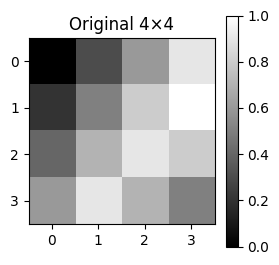

In [15]:
# 创建一个简单的4×4渐变图像
small_img = np.array([
    [0.0, 0.3, 0.6, 0.9],
    [0.2, 0.5, 0.8, 1.0],
    [0.4, 0.7, 0.9, 0.8],
    [0.6, 0.9, 0.7, 0.5]
])

print("Original Pic (4×4):")
print(small_img)
print(f"Shape: {small_img.shape}")

# 可视化
plt.figure(figsize=(3, 3))
plt.imshow(small_img, cmap='gray', interpolation='nearest')
plt.title("Original 4×4")
plt.colorbar()
plt.show()

## 2. Nearest Neighbor (最近邻插值)

直接复制最近的像素值，速度快但有锯齿

上采样后形状: (16, 16)
像素数量: 256 个像素
实际是 16×16 的图像，每个像素都有值


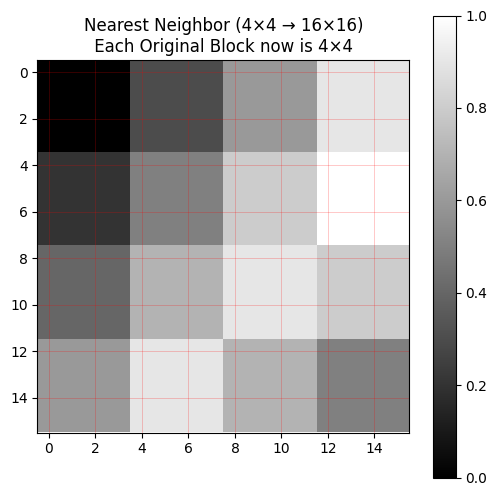

In [39]:
# 使用 PyTorch 进行最近邻上采样
img_tensor = torch.from_numpy(small_img).unsqueeze(0).unsqueeze(0).float()

upsample_nearest = nn.Upsample(scale_factor=4, mode='nearest')
upsampled_nearest = upsample_nearest(img_tensor).squeeze().numpy()

print(f"上采样后形状: {upsampled_nearest.shape}")
print(f"像素数量: {upsampled_nearest.size} 个像素")
print(f"实际是 16×16 的图像，每个像素都有值")

plt.figure(figsize=(6, 6))
plt.imshow(upsampled_nearest, cmap='gray', interpolation='none')  # 使用 'none' 显示真实像素
plt.title("Nearest Neighbor (4×4 → 16×16)\n Each Original Block now is 4×4 ", fontsize=12)

plt.colorbar()
plt.grid(True, which='both', color='red', linewidth=0.5, alpha=0.3)
plt.show()


## 3. Bilinear (双线性插值)

对周围4个像素加权平均，结果更平滑

上采样后形状: (16, 16)
像素数量: 256 个像素
双线性插值：周围4个像素加权平均


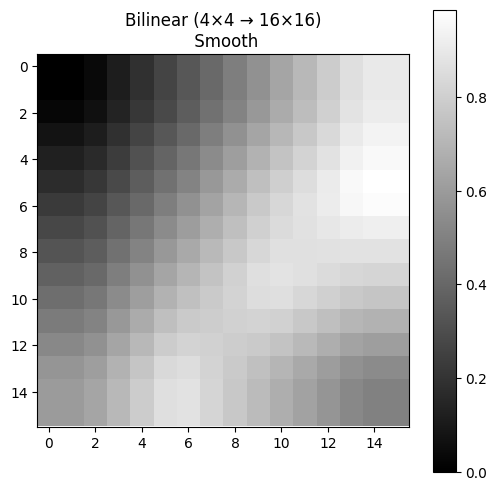

In [22]:
# 使用 PyTorch 进行双线性上采样
upsample_bilinear = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False)
upsampled_bilinear = upsample_bilinear(img_tensor).squeeze().numpy()

print(f"上采样后形状: {upsampled_bilinear.shape}")
print(f"像素数量: {upsampled_bilinear.size} 个像素")
print(f"双线性插值：周围4个像素加权平均")

plt.figure(figsize=(6, 6))
plt.imshow(upsampled_bilinear, cmap='gray', interpolation='none')  # 显示真实的 16×16 像素
plt.title("Bilinear (4×4 → 16×16)\n Smooth", fontsize=12)

plt.colorbar()
plt.show()

## 4. Bicubic (双三次插值)

对周围16个像素加权平均，质量最高但计算稍慢

上采样后形状: (16, 16)
像素数量: 256 个像素


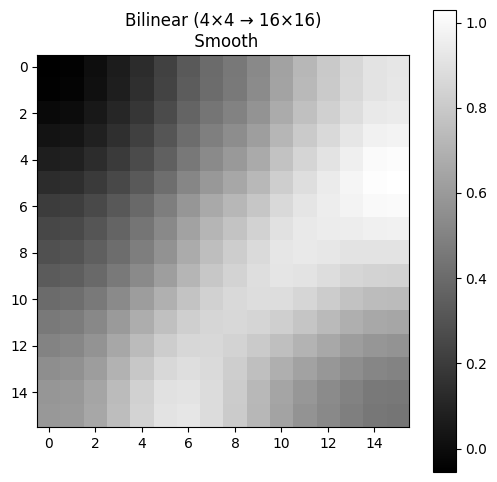

In [35]:
# 使用 PyTorch 进行bicubic采样
upsample_bicubic = nn.Upsample(scale_factor=4, mode='bicubic', align_corners=False)
upsampled_bicubic = upsample_bilinear(img_tensor).squeeze().numpy()

print(f"上采样后形状: {upsampled_bicubic.shape}")
print(f"像素数量: {upsampled_bicubic.size} 个像素")

plt.figure(figsize=(6, 6))
plt.imshow(upsampled_bicubic, cmap='gray', interpolation='none')  # 显示真实的 16×16 像素
plt.title("Bilinear (4×4 → 16×16)\n Smooth", fontsize=12)

plt.colorbar()
plt.show()

## 5. 并排对比所有方法

看清楚不同插值方法的实际效果

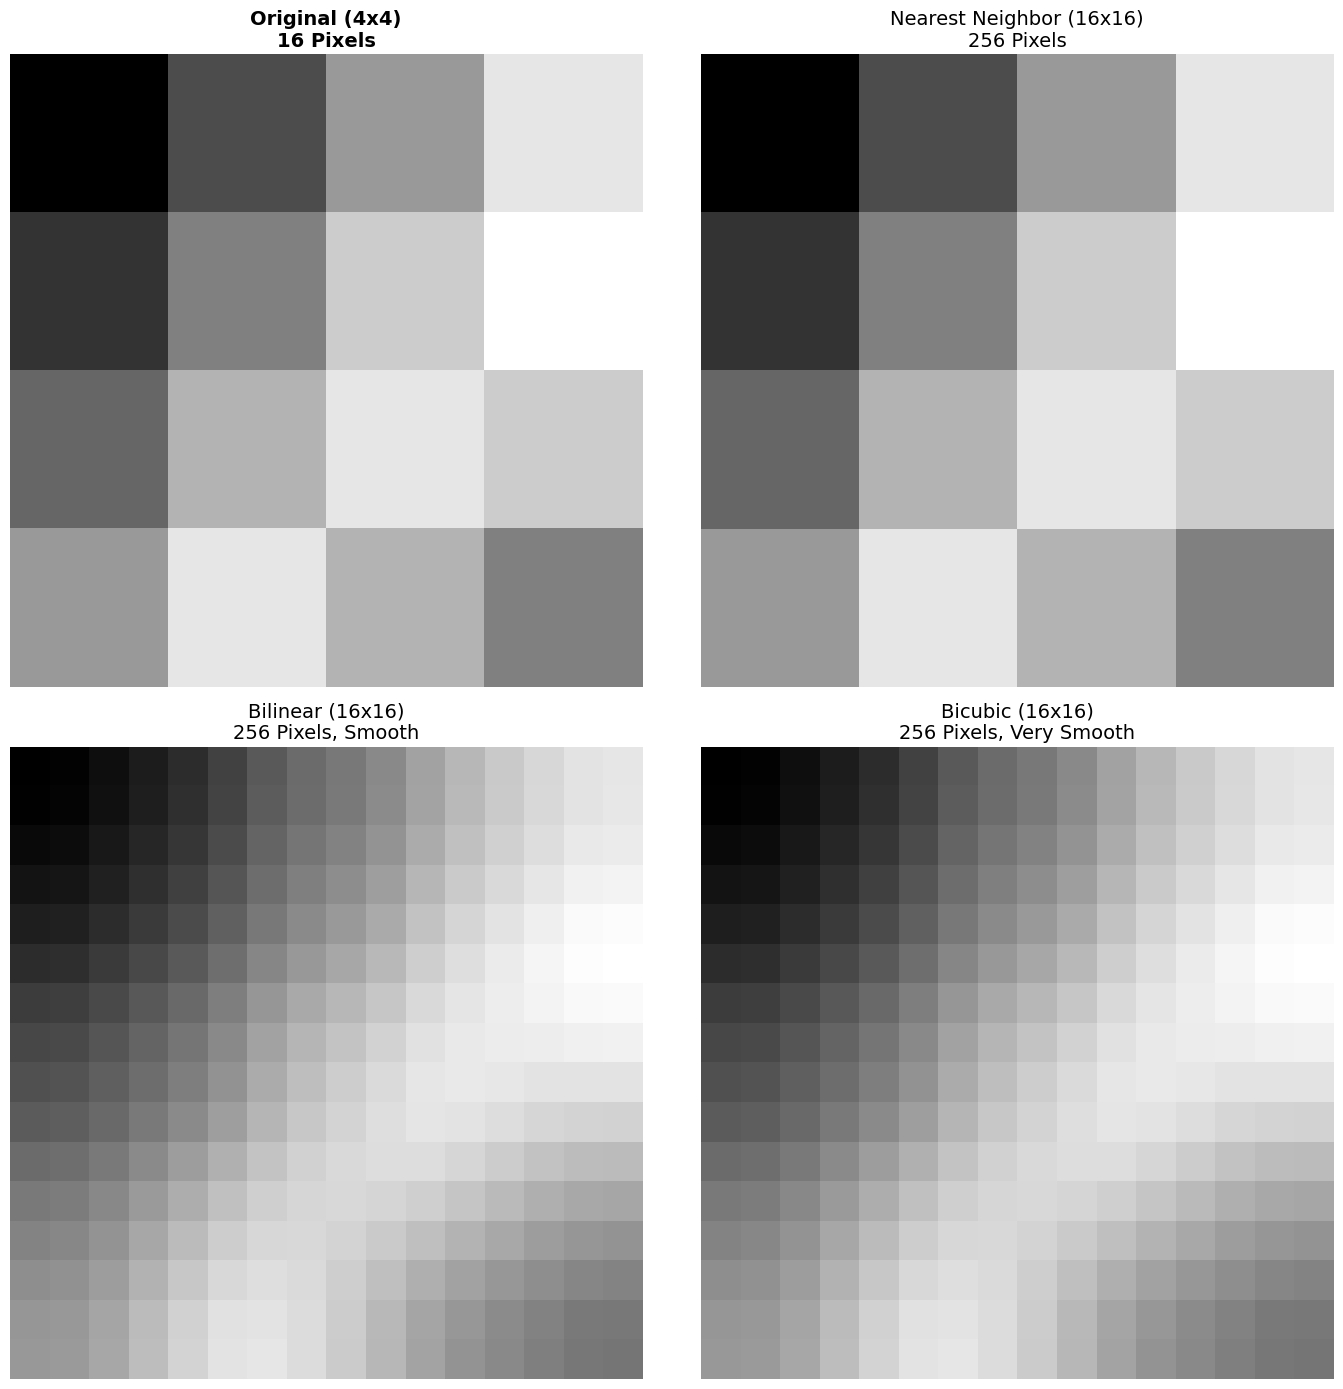


关键区别:
原始:    (4, 4) = 16 个像素
Nearest: (16, 16) = 256 个像素 (每个原始像素→4×4块)
Bilinear: (16, 16) = 256 个像素 (插值平滑)
Bicubic: (16, 16) = 256 个像素 (最平滑)


In [29]:
# 并排对比所有上采样方法
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# 原始图像
axes[0, 0].imshow(small_img, cmap='gray', interpolation='none')
axes[0, 0].set_title("Original (4x4)\n16 Pixels", fontsize=14, fontweight='bold')
axes[0, 0].grid(True, which='both', color='white', linewidth=1, alpha=0.5)

# Nearest Neighbor
axes[0, 1].imshow(upsampled_nearest, cmap='gray', interpolation='none')
axes[0, 1].set_title("Nearest Neighbor (16x16)\n256 Pixels", fontsize=14)
axes[0, 1].grid(True, which='both', color='red', linewidth=0.5, alpha=0.2)

# Bilinear
axes[1, 0].imshow(upsampled_bilinear, cmap='gray', interpolation='none')
axes[1, 0].set_title("Bilinear (16x16)\n256 Pixels, Smooth", fontsize=14)

# Bicubic
axes[1, 1].imshow(upsampled_bicubic, cmap='gray', interpolation='none')
axes[1, 1].set_title("Bicubic (16x16)\n256 Pixels, Very Smooth", fontsize=14)

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n关键区别:")
print("="*60)
print(f"原始:    {small_img.shape} = {small_img.size} 个像素")
print(f"Nearest: {upsampled_nearest.shape} = {upsampled_nearest.size} 个像素 (每个原始像素→4×4块)")
print(f"Bilinear: {upsampled_bilinear.shape} = {upsampled_bilinear.size} 个像素 (插值平滑)")
print(f"Bicubic: {upsampled_bicubic.shape} = {upsampled_bicubic.size} 个像素 (最平滑)")


上采样后形状: (16, 16)
像素数量: 256 个像素
双线性插值：周围4个像素加权平均


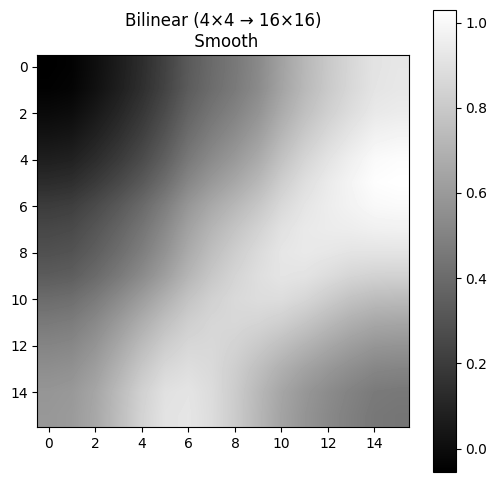

In [34]:
# 在plt.imshow 中使用双线性插值，显示为渐变
upsample_bicubic = nn.Upsample(scale_factor=4, mode='bicubic', align_corners=False)
upsampled_bicubic = upsample_bilinear(img_tensor).squeeze().numpy()

print(f"上采样后形状: {upsampled_bicubic.shape}")
print(f"像素数量: {upsampled_bicubic.size} 个像素")
print(f"Bicubic：周围4个像素加权平均")

plt.figure(figsize=(6, 6))
plt.imshow(upsampled_bicubic, cmap='gray', interpolation='bilinear')  # 
plt.title("Bilinear (4×4 → 16×16)\n Smooth", fontsize=12)

plt.colorbar()
plt.show()

上采样后形状: (16, 16)
像素数量: 256 个像素
Bicubic：周围4个像素加权平均


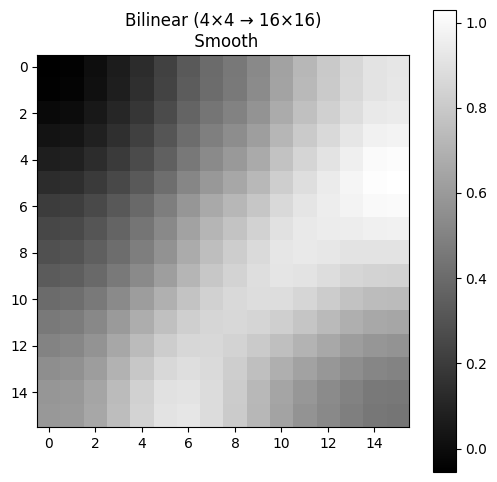

In [37]:
# 对角化bicubic上采样生成
upsample_bicubic = nn.Upsample(scale_factor=4, mode='bicubic', align_corners=True)
upsampled_bicubic = upsample_bilinear(img_tensor).squeeze().numpy()

print(f"上采样后形状: {upsampled_bicubic.shape}")
print(f"像素数量: {upsampled_bicubic.size} 个像素")
print(f"Bicubic：周围4个像素加权平均")

plt.figure(figsize=(6, 6))
plt.imshow(upsampled_bicubic, cmap='gray', interpolation='none')  # 
plt.title("Bilinear (4×4 → 16×16)\n Smooth", fontsize=12)

plt.colorbar()
plt.show()

## 6. DCGAN中的应用

在DCGAN的Generator中，我们使用 `Upsample(mode='bilinear')` + `Conv2d` 的组合

In [38]:
# DCGAN Generator 中的上采样块示例
class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=True)
        )
    
    def forward(self, x):
        return self.block(x)

# 演示: 7×7 → 14×14
demo_input = torch.randn(1, 128, 7, 7)
upsample_block = UpsampleBlock(128, 64)

demo_output = upsample_block(demo_input)
print(f"输入形状: {demo_input.shape}")
print(f"输出形状: {demo_output.shape}")
print(f"\n参数数量: {sum(p.numel() for p in upsample_block.parameters()):,}")

print("\n优势:")
print("✓ 避免 ConvTranspose2d 的棋盘效应")
print("✓ 参数量更少，训练更快")
print("✓ 生成质量更稳定")

输入形状: torch.Size([1, 128, 7, 7])
输出形状: torch.Size([1, 64, 14, 14])

参数数量: 74,048

优势:
✓ 避免 ConvTranspose2d 的棋盘效应
✓ 参数量更少，训练更快
✓ 生成质量更稳定
